In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('cheating_detection_dataset_4.csv')
df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   participant_id               5010 non-null   int64  
 1   competition_id               5010 non-null   int64  
 2   total_submissions            5010 non-null   int64  
 3   active_days                  5010 non-null   int64  
 4   submissions_per_day          5010 non-null   float64
 5   submission_avg_initial_days  5010 non-null   float64
 6   avg_submissions_mid          5010 non-null   float64
 7   submissions_end              5010 non-null   int64  
 8   median_score                 5010 non-null   float64
 9   top_score                    5010 non-null   float64
 10  lowest_score                 5010 non-null   float64
 11  gap_median_top               5010 non-null   float64
 12  gap_lowest_top               5010 non-null   float64
 13  peak_submissions_p

In [3]:
df.describe()

,participant_id,competition_id,total_submissions,active_days,submissions_per_day,submission_avg_initial_days,avg_submissions_mid,submissions_end,median_score,top_score,...,above_below_claude_min,score_time_corr,time_to_best_score_hours,post_jump_score_repetition,quiz_participation,final_rank,rank_to_submissions,rank_to_quiz_participation,description_rate,cheated
count,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,...,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,2505.500000,81.760878,17.050100,5.986427,2.943809,1.274584,1.850566,2.058084,1.125471,0.639125,...,0.587226,-0.651618,134.999983,0.322514,5.749701,17.302395,2.129755,2.865460,0.731921,0.323353
std,1446.406755,46.213924,10.231152,2.737650,1.428400,1.081569,1.455606,2.490313,0.480451,0.327723,...,0.492382,0.404377,79.201862,0.359877,1.786136,10.803189,3.674015,2.402233,0.153076,0.467803
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.383584,0.300000,...,0.000000,-1.000000,0.000000,0.000000,0.000000,1.000000,0.015873,0.100000,0.000000,0.000000
25%,1253.250000,42.000000,9.000000,4.000000,2.000000,0.333333,0.666667,0.000000,0.650485,0.440747,...,0.000000,-0.928661,52.319197,0.000000,5.000000,8.000000,0.457143,1.250000,0.654000,0.000000
50%,2505.500000,83.000000,16.000000,6.000000,2.625000,1.000000,1.666667,1.000000,1.121701,0.542338,...,1.000000,-0.771813,163.593138,0.156943,6.000000,16.000000,1.000000,2.400000,0.750000,0.000000
75%,3757.750000,122.000000,23.000000,8.000000,3.500000,2.000000,2.666667,3.000000,1.488934,0.719577,...,1.000000,-0.580366,202.215623,0.656882,7.000000,25.000000,2.066667,3.833333,0.828000,1.000000
max,5010.000000,160.000000,75.000000,10.000000,10.000000,6.000000,8.666667,10.000000,2.554217,2.547187,...,1.000000,1.000000,239.468945,1.000000,10.000000,46.000000,45.000000,39.000000,1.000000,1.000000


In [4]:
df = df.drop(columns = ['participant_id','competition_id'])
df


,total_submissions,active_days,submissions_per_day,submission_avg_initial_days,avg_submissions_mid,submissions_end,median_score,top_score,lowest_score,gap_median_top,...,above_below_claude_min,score_time_corr,time_to_best_score_hours,post_jump_score_repetition,quiz_participation,final_rank,rank_to_submissions,rank_to_quiz_participation,description_rate,cheated
0,4,3,1.333333,0.000000,0.333333,0,1.746106,0.816072,2.261419,0.930035,...,0,-0.011546,54.451199,1.000000,5,15,3.750000,2.500000,0.500,0
1,21,8,2.625000,1.333333,2.000000,2,1.397039,0.505444,2.316454,0.891595,...,1,-0.979707,206.666833,0.590711,5,7,0.333333,1.166667,0.762,0
2,26,8,3.250000,0.333333,3.333333,9,1.148055,0.650068,2.475498,0.497987,...,0,-0.859866,184.343915,0.000000,6,13,0.500000,1.857143,0.808,0
3,12,6,2.000000,1.333333,1.333333,0,1.218825,1.005571,2.417817,0.213254,...,0,-0.742232,139.212423,0.000000,6,18,1.500000,2.571429,0.833,0
4,29,10,2.900000,2.666667,3.666667,4,0.494276,0.351093,1.266685,0.143183,...,1,-0.827912,227.077013,0.000000,8,2,0.068966,0.222222,0.828,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5005,29,7,4.142857,2.333333,4.000000,10,1.755678,0.395010,2.125157,1.360668,...,1,-0.897306,217.021732,0.566223,6,6,0.206897,0.857143,0.690,1
5006,29,10,2.900000,2.666667,3.000000,2,0.582251,0.409273,1.065152,0.172978,...,1,-0.721619,148.566853,0.531388,7,7,0.241379,0.875000,0.655,0
5007,9,6,1.500000,0.666667,0.000000,2,1.055534,0.566114,2.038870,0.489421,...,0,-0.870999,195.032120,0.000000,5,24,2.666667,4.000000,0.889,0
5008,24,9,2.666667,3.666667,3.000000,1,1.275355,0.644566,1.999642,0.630789,...,0,-0.962020,207.707779,0.000000,6,28,1.166667,4.000000,0.667,1


In [5]:
print(df.duplicated().sum())
df = df[df.duplicated() == False]
print(df.duplicated().sum())
df.head()
df.shape

0
0


(5010, 27)

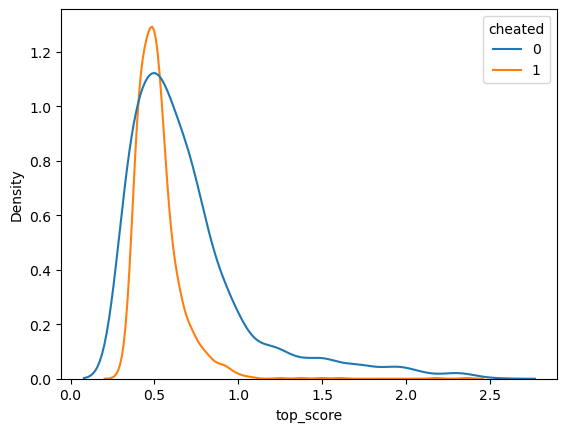

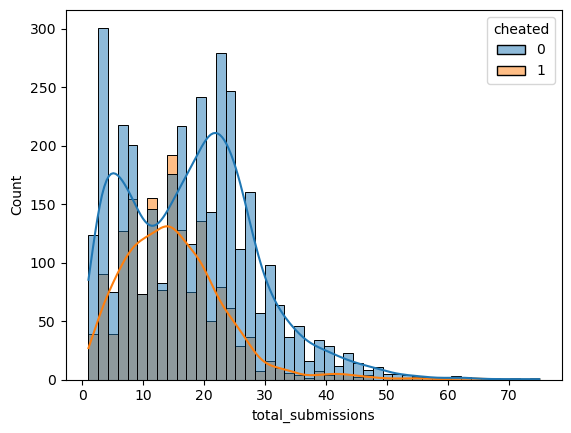

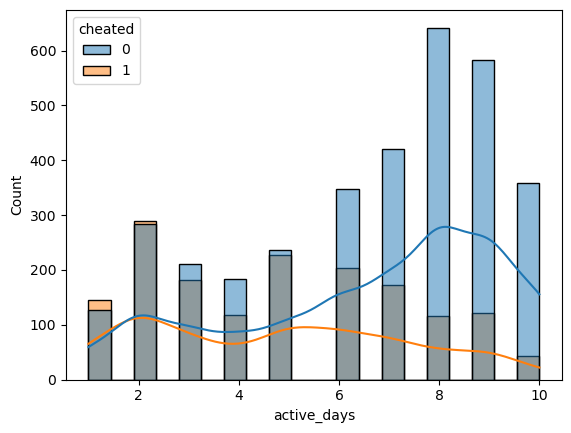

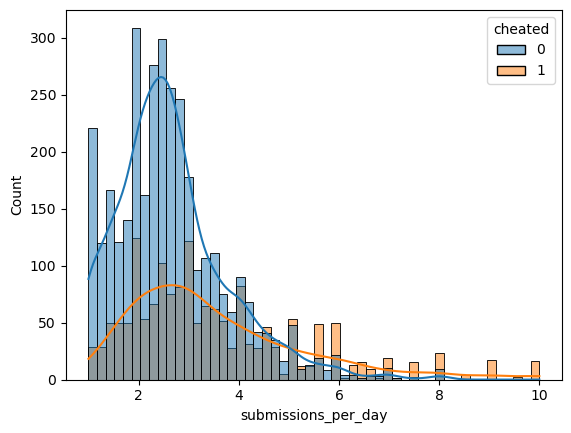

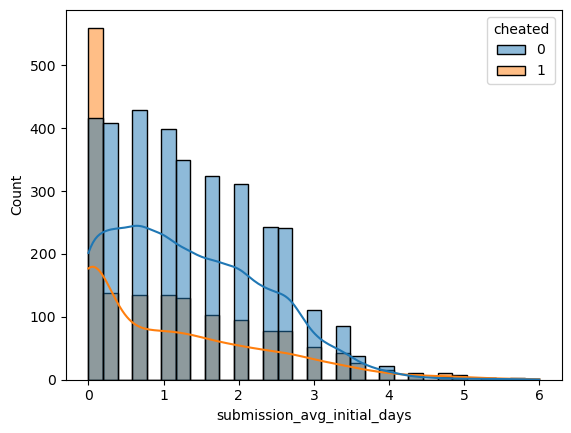

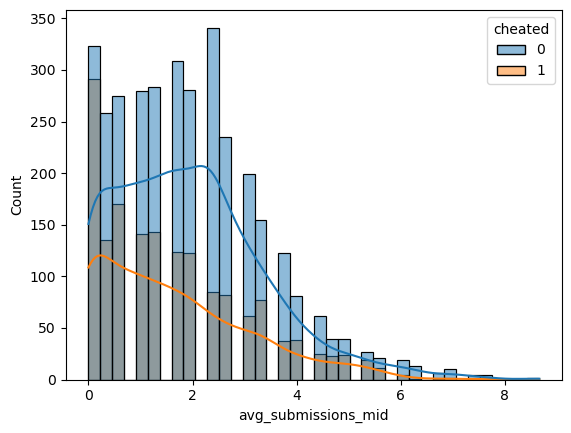

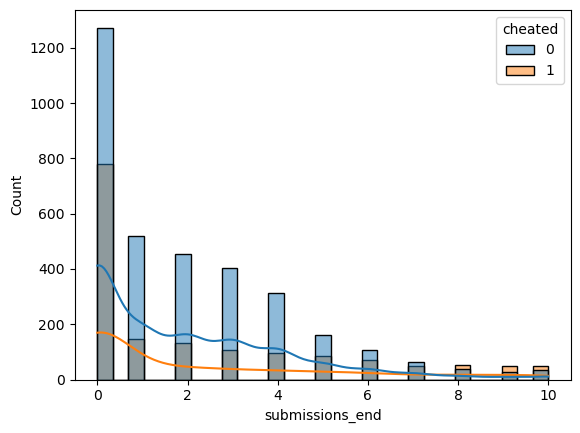

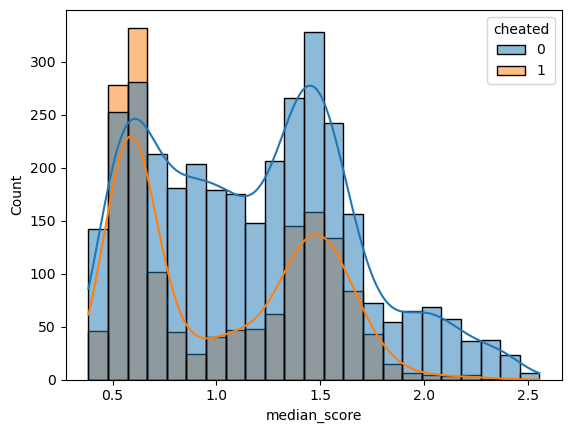

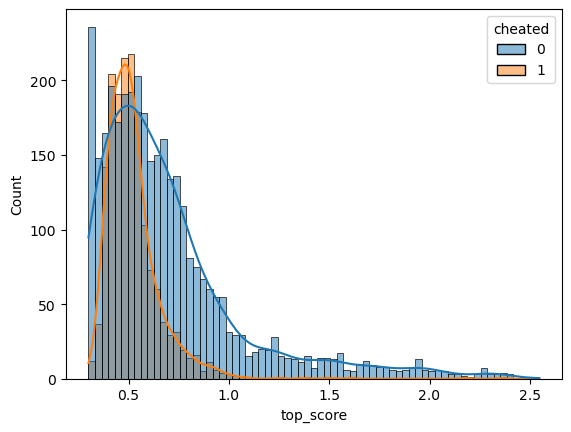

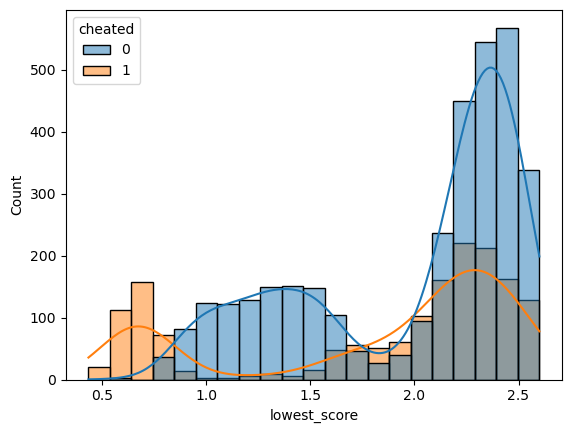

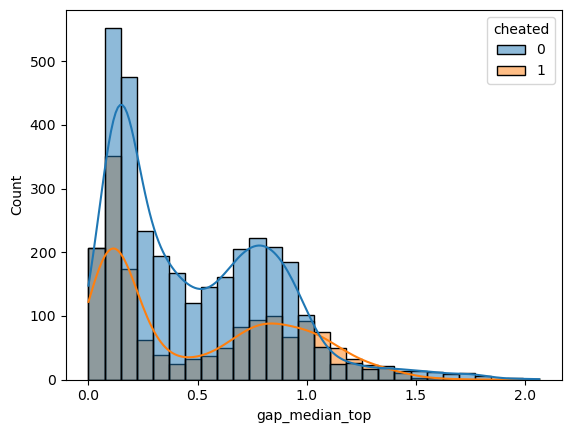

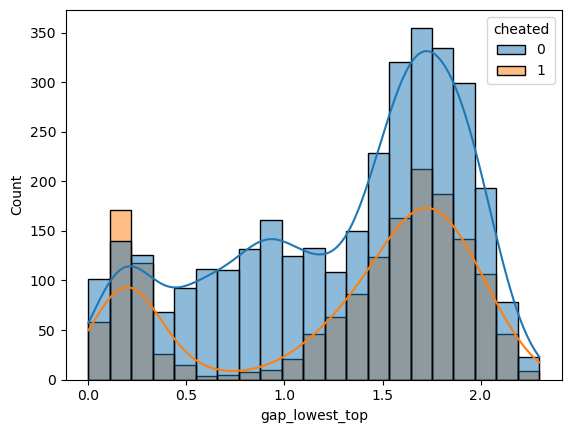

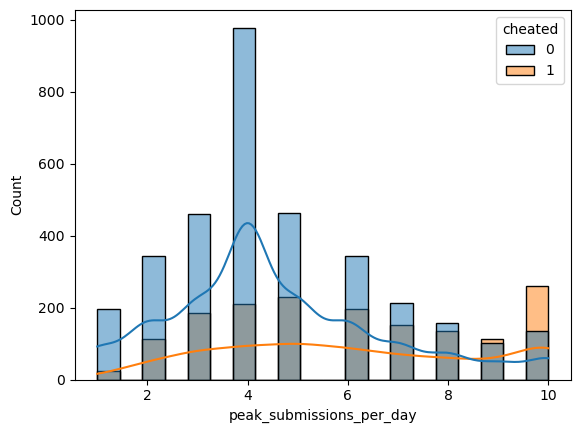

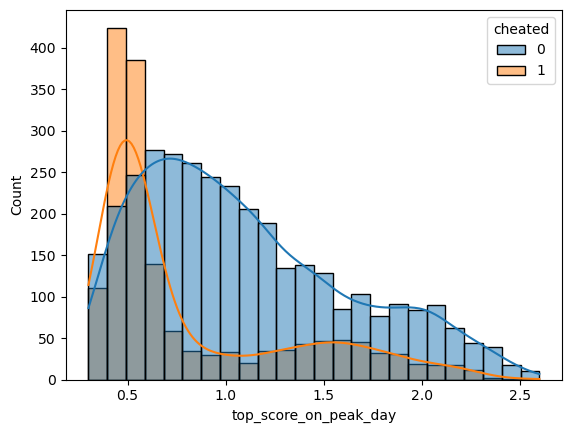

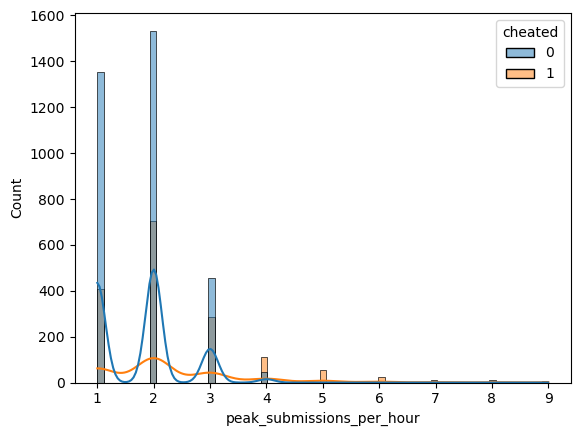

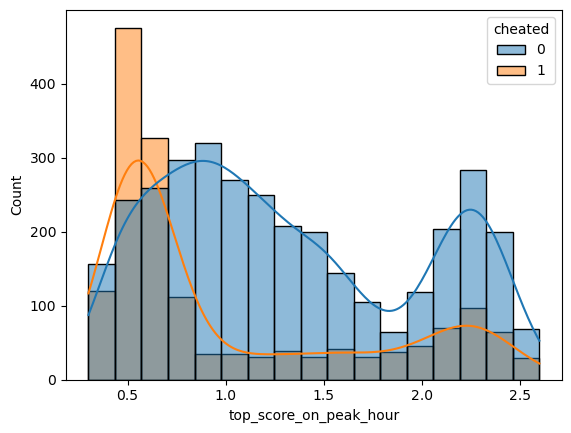

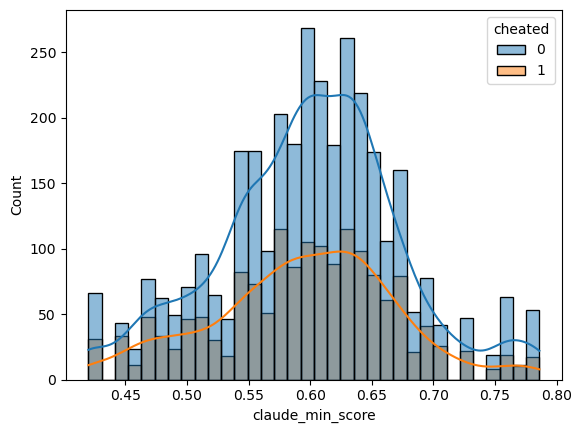

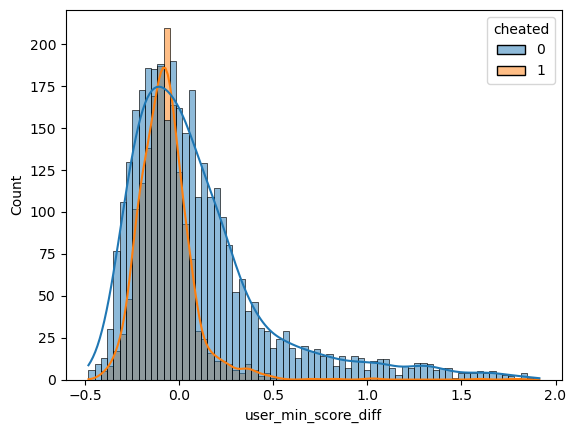

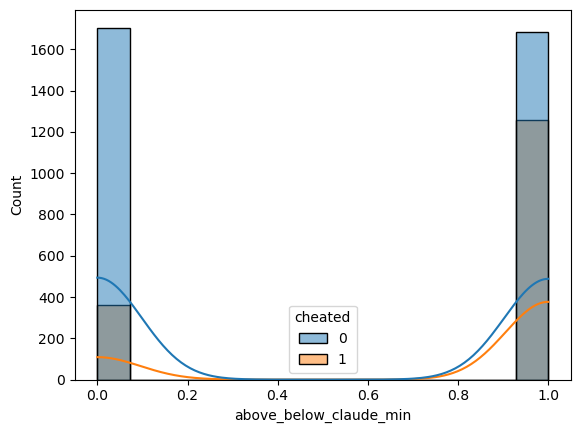

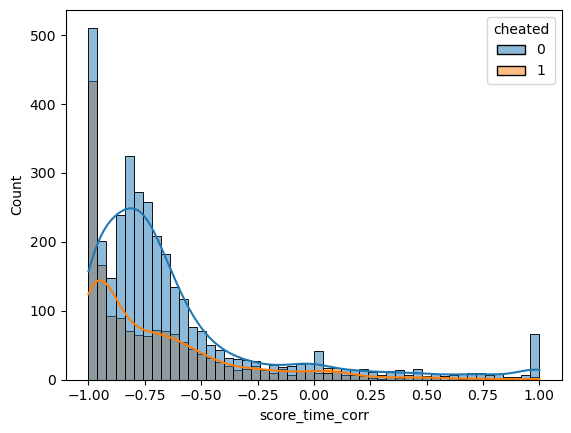

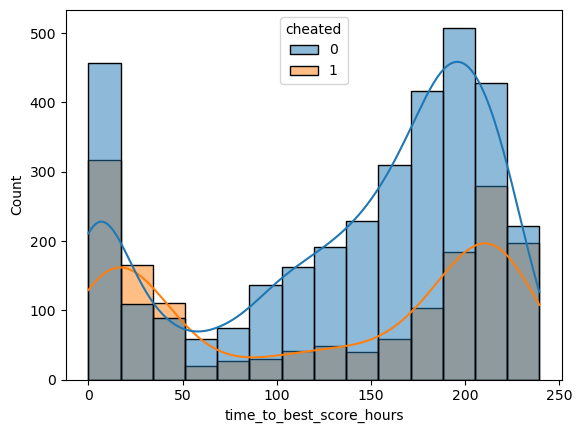

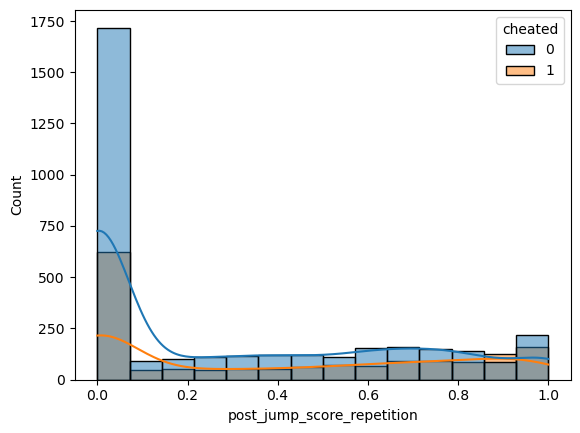

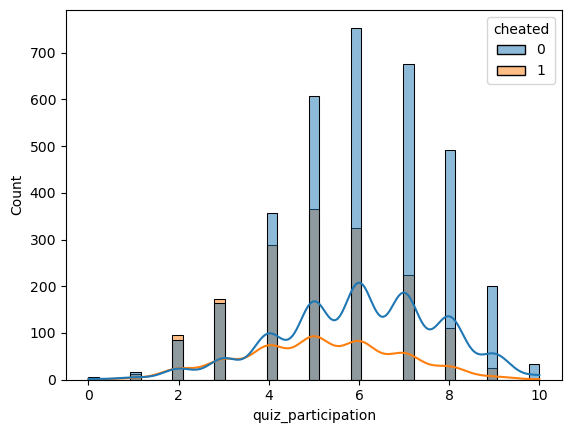

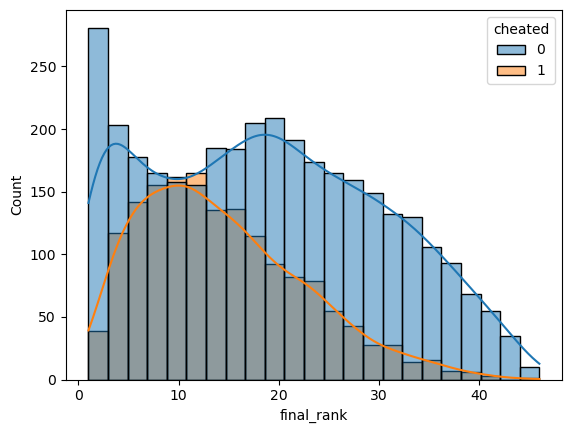

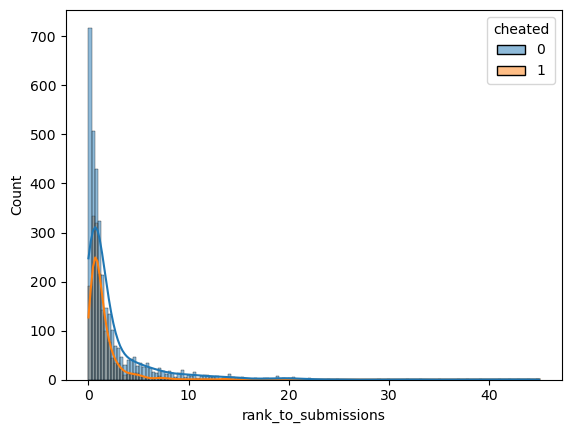

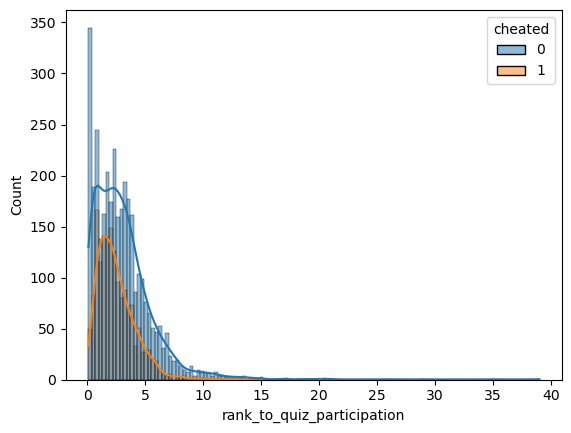

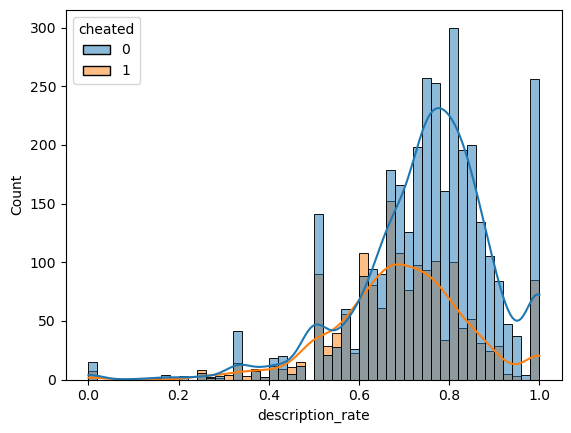

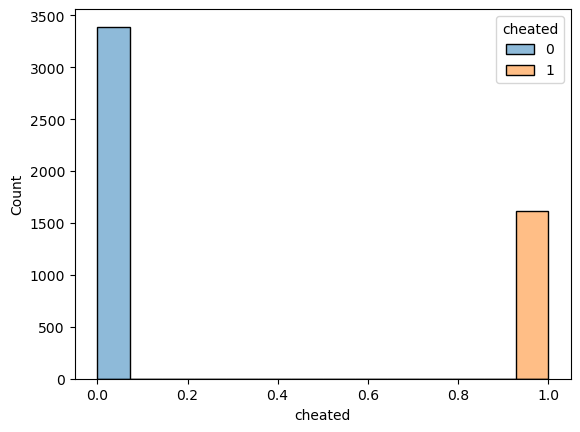

{'active_days': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 'peak_submissions_per_hour': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
 'peak_submissions_per_day': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 'quiz_participation': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 'final_rank': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46])}

In [6]:
sns.kdeplot(data = df, x= 'top_score', hue = 'cheated')
plt.show()
plt.close()
for i in df.columns:
    sns.histplot(data = df, x= i, hue = 'cheated', kde=True)
    plt.show()
    plt.close()

# display(df2['BMI'].describe())
# df['BMI'].describe()
cat_columns = ['active_days', 'peak_submissions_per_hour', 'peak_submissions_per_day', 'quiz_participation','final_rank', 'cheated']
d = {i:np.sort(df[i].unique()) for i in cat_columns}
d.pop('cheated')
d

In [7]:
cheated = df['cheated'].sum()
cat_columns = ['active_days', 'peak_submissions_per_hour', 'peak_submissions_per_day', 'quiz_participation','final_rank']
for i in cat_columns:
    if i == 'cheated':
        continue
    print(i)
    for j in d[i]:
        a = df[df[i] == j]
        b = a['cheated'].sum()
        
        print(f"       {j} :\n       Probability of cheating = {(b*100)/(a.shape[0])}       [[TD:{a.shape[0]} '+' :{b}]]\n       overall '+'ve contribution : {(b*100)/(cheated)}")

active_days
       1 :
       Probability of cheating = 53.30882352941177       [[TD:272 '+' :145]]
       overall '+'ve contribution : 8.950617283950617
       2 :
       Probability of cheating = 50.610820244328096       [[TD:573 '+' :290]]
       overall '+'ve contribution : 17.901234567901234
       3 :
       Probability of cheating = 46.42857142857143       [[TD:392 '+' :182]]
       overall '+'ve contribution : 11.234567901234568
       4 :
       Probability of cheating = 39.20265780730897       [[TD:301 '+' :118]]
       overall '+'ve contribution : 7.283950617283951
       5 :
       Probability of cheating = 48.922413793103445       [[TD:464 '+' :227]]
       overall '+'ve contribution : 14.012345679012345
       6 :
       Probability of cheating = 37.023593466424686       [[TD:551 '+' :204]]
       overall '+'ve contribution : 12.592592592592593
       7 :
       Probability of cheating = 29.124579124579125       [[TD:594 '+' :173]]
       overall '+'ve contribution : 10.6

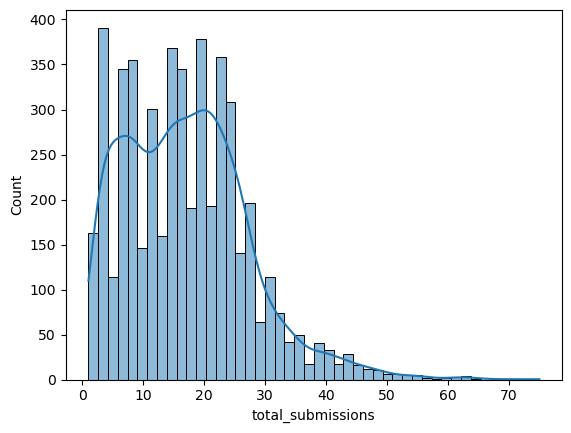

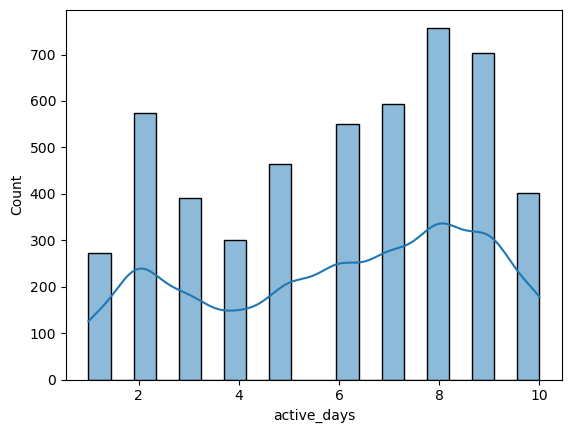

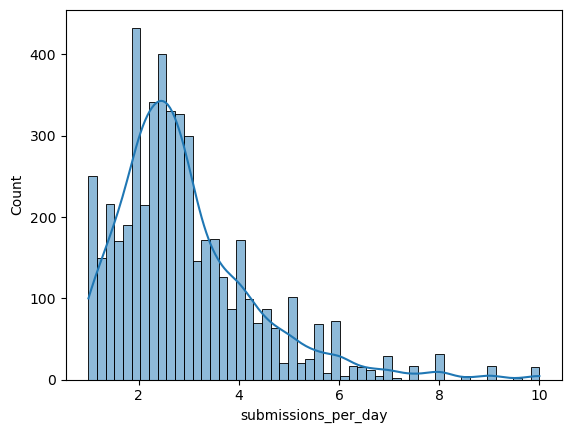

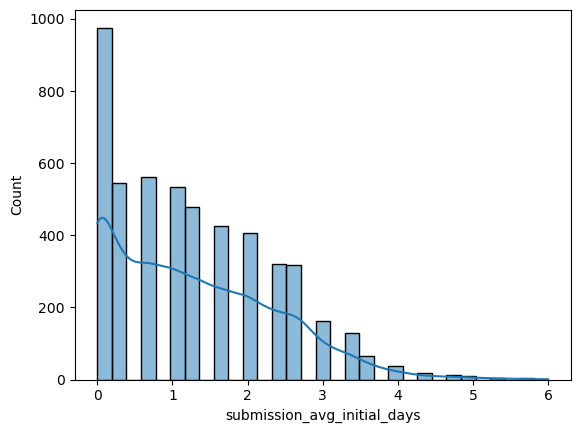

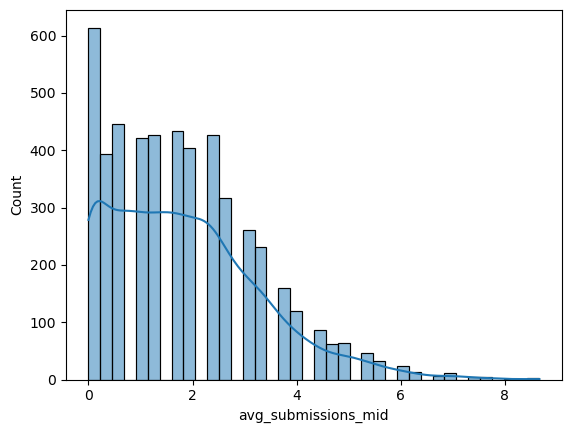

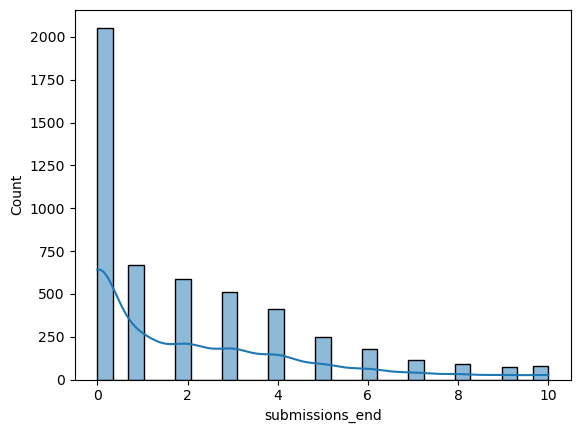

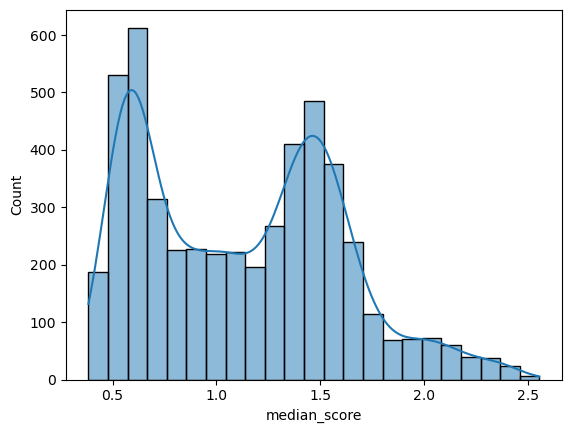

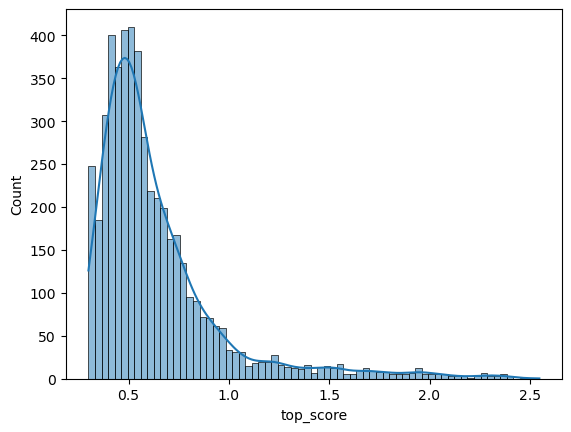

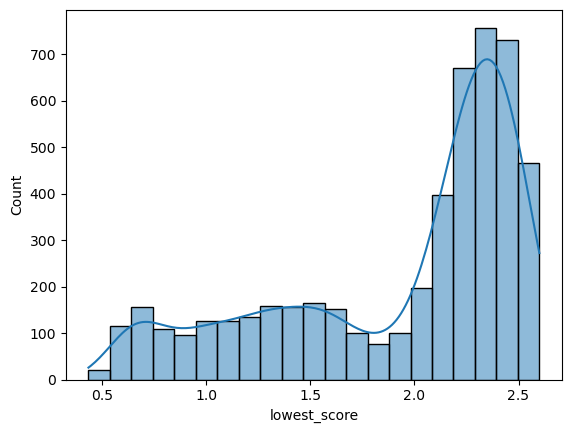

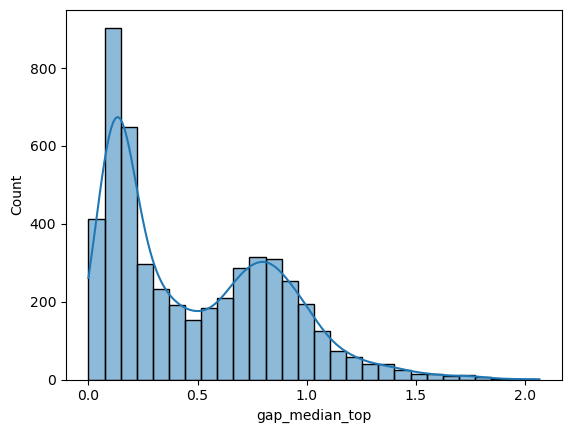

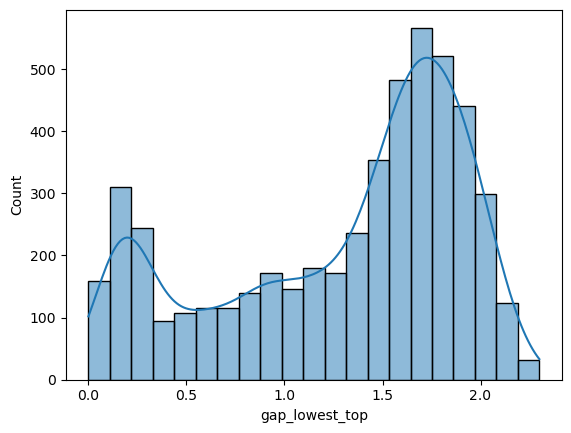

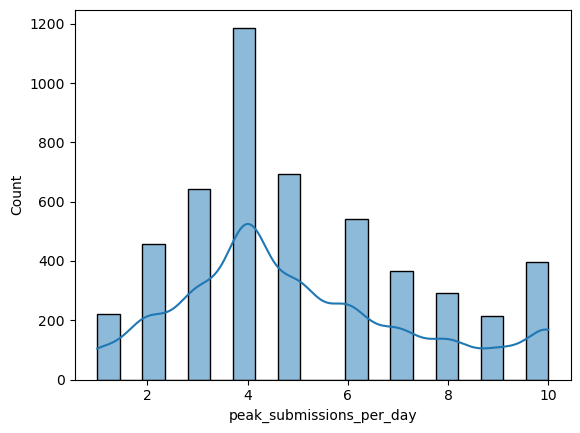

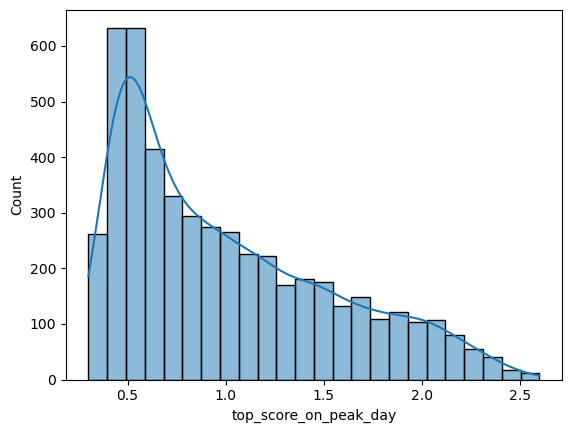

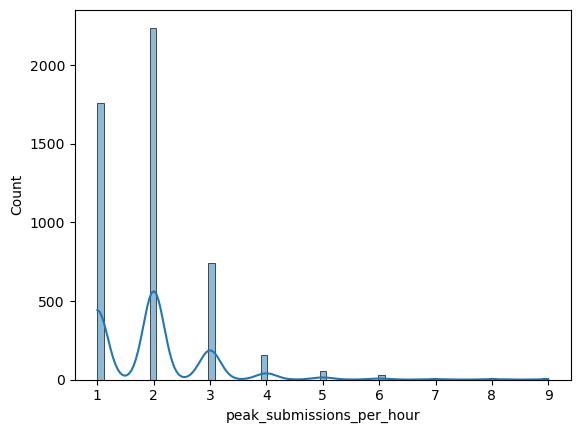

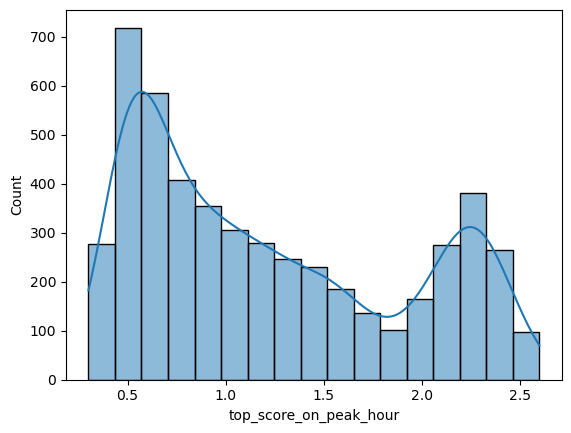

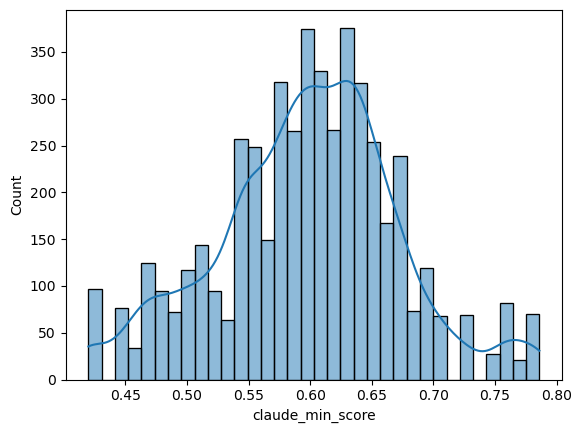

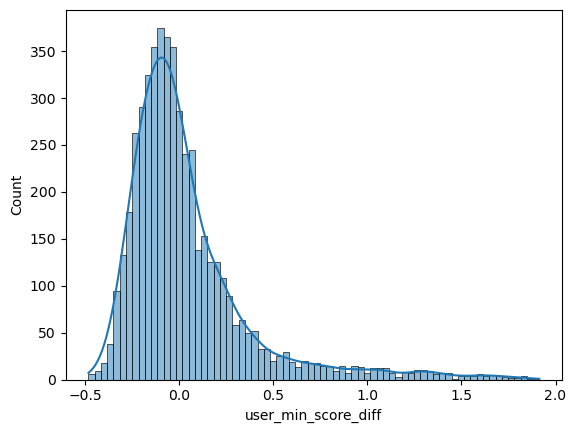

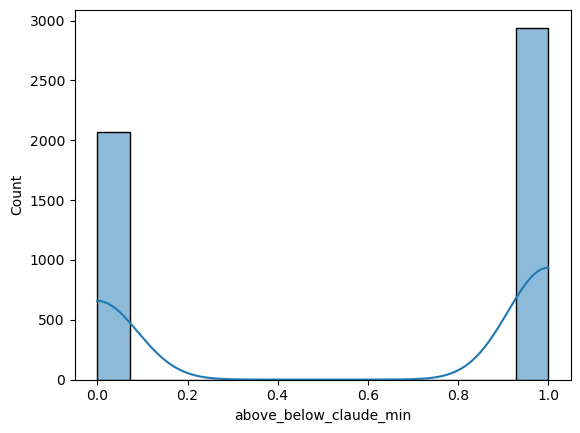

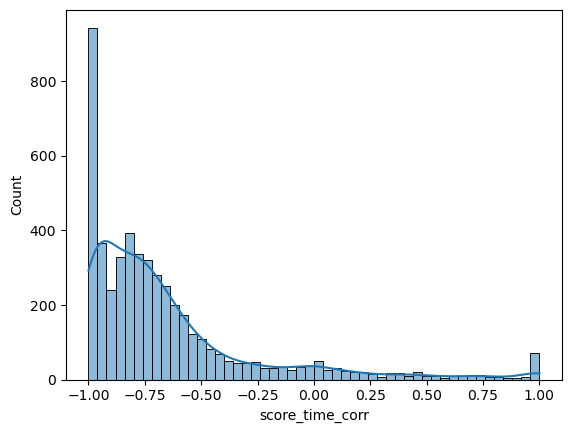

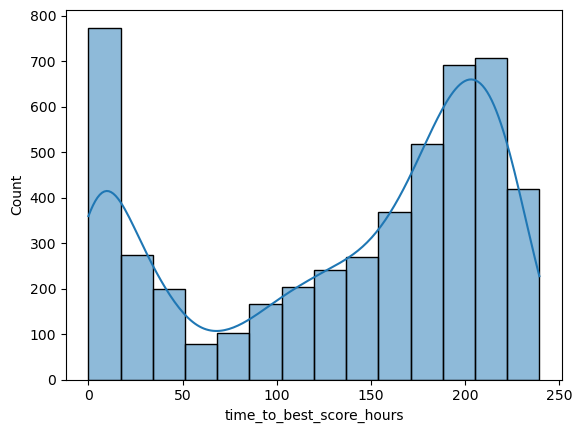

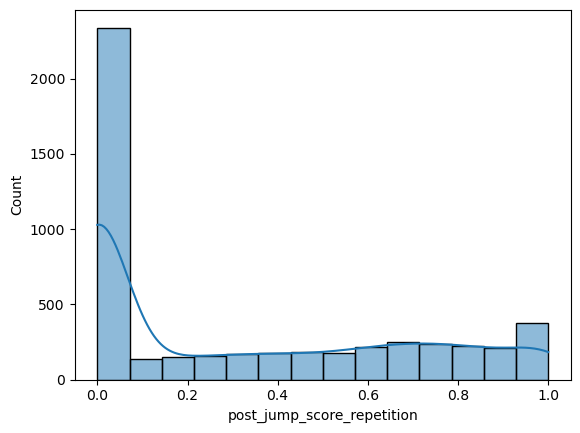

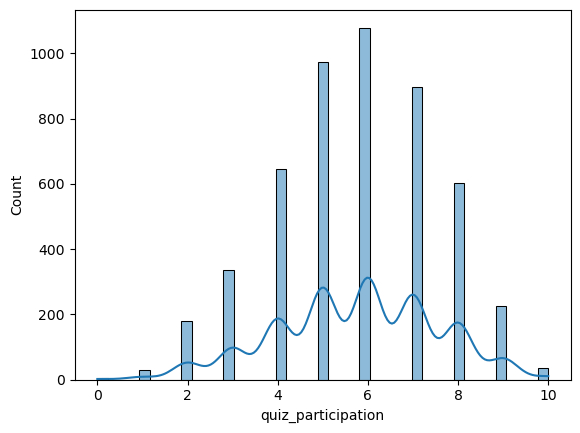

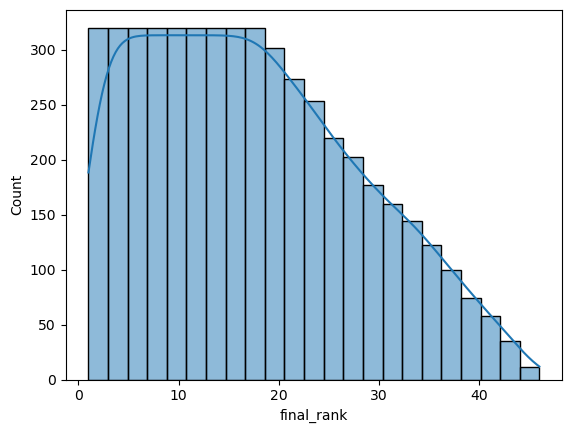

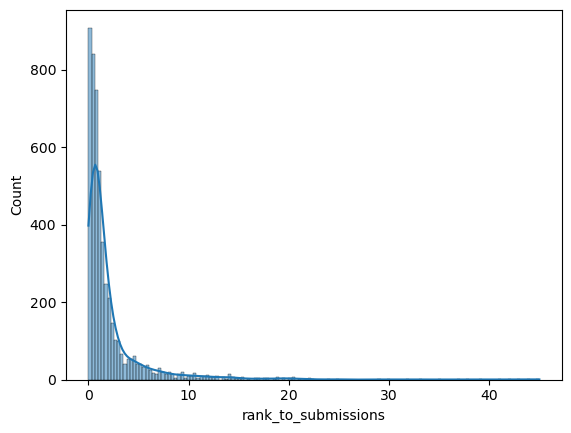

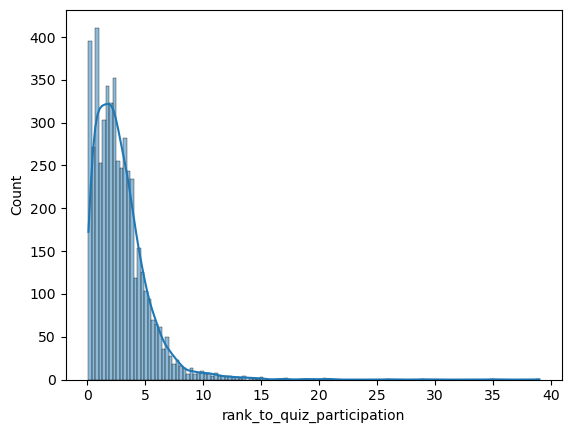

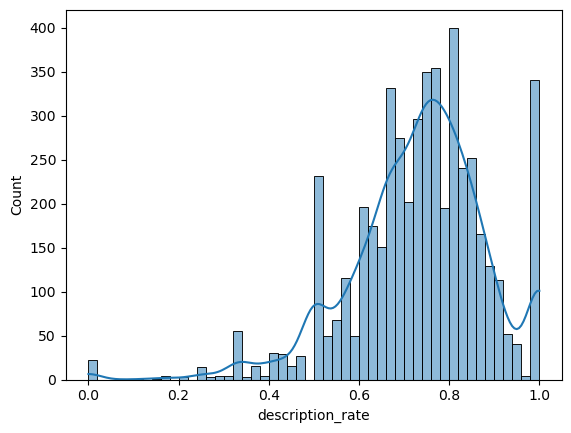

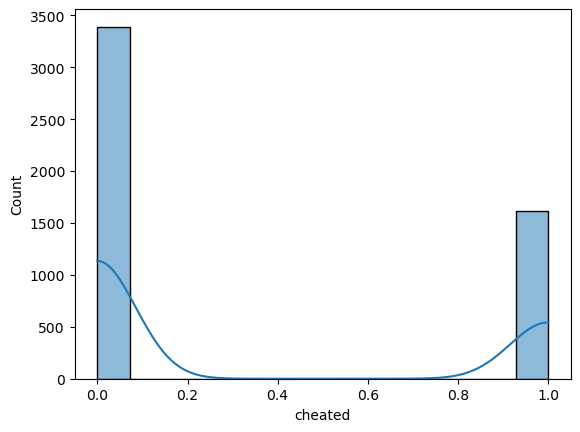

In [8]:
for i in df.columns:
    sns.histplot(data = df, x= i, kde=True)
    plt.show()
    plt.close()